In [1]:
# Libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.spatial
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr

In [2]:
# Parse docking results for new ligands
dir_at_cav = "swissdock_results\ligands"
dicc_ligands = {}
list_dicc = []
for dir in os.listdir(dir_at_cav):
    file_dock = dir_at_cav + "\\" + dir + "\\result.dock4"
    dicc_all = {}
    list_blocks = []
    block = 1
    with open(file_dock, "r") as f:
        for line in f:
            stripped_line = line.strip()
            list_blocks.append(stripped_line)

            if line.startswith('TER'):
                dicc_all[block] = list_blocks
                list_blocks = []
                block += 1
    if list_blocks:
        dicc_all[block] = list_blocks

    dicc_ligands[dir] = dicc_all

In [3]:
dir_outputs = "ligands_PDBs"
# Save the dock4 poses of the ligands as PDB files for visualization in PyMOL
if True:
    for key in dicc_ligands.keys():
        output = dir_outputs + "\\" + key + ".pdb"
        file_dock = dir_at_cav + "\\" + key + "\\result.dock4"
        with open(file_dock, "r") as infile, open(output, "w") as outfile:
            model = 1
            outfile.write(f"MODEL     {model}\n")
            for line in infile:
                if line.startswith("TER"):
                    outfile.write("ENDMDL\n")
                    model += 1
                    outfile.write(f"MODEL     {model}\n")
                elif line.startswith(("ATOM", "HETATM", "REMARK")):
                    outfile.write(line)
            outfile.write("ENDMDL\n")

In [4]:
# Parse SwissDock output files and extract docking metadata and atomic coordinates
dicc_remarks_master = {}
dicc_coords_master = {}
dicc_frames = {}
for ligand in dicc_ligands.keys():
    dicc_remarks = {}
    dicc_coords = {}
    for key in dicc_ligands[ligand].keys():
        new_key = dicc_ligands[ligand][key][0].split(' ')[-1]
        new_key = new_key.split('.')[0]
        dicc_frames[ligand + '_' + new_key] = key
        dicc_remarks[new_key] = {}
        dicc_coords[new_key] = []
        for elem in dicc_ligands[ligand][key]:
            if 'REMARK' in elem:
                elem_parts = elem.split()
                field = elem_parts[1]
                value = elem_parts[-1]
                dicc_remarks[new_key][field] = value
            elif 'ATOM' in elem:
                dicc_coords[new_key].append(elem)
    dicc_remarks_master[ligand] = dicc_remarks
    dicc_coords_master[ligand] = dicc_coords

In [5]:
# Build a DataFrame containing docking scores and metadata for all ligand poses
dfs = []

for ligand, dicc in dicc_remarks_master.items():
    df = pd.DataFrame.from_dict(dicc, orient='index')
    df["ligand"] = ligand
    dfs.append(df)

df_remarks = pd.concat(dfs, ignore_index=True)

df_remarks[['MEMBER_ENERGY', 'MEMBER_SCORE', 'SP-dG', 'Polar', 
            'Nonpolar', 'Inter', 'Polar15', 'RMSD']] = \
    df_remarks[['MEMBER_ENERGY', 'MEMBER_SCORE', 'SP-dG', 'Polar',
                'Nonpolar', 'Inter', 'Polar15', 'RMSD']].astype(float)

df_remarks[['CLUSTER_NUM', 'CLUSTER_MEMBER']] = \
    df_remarks[['CLUSTER_NUM', 'CLUSTER_MEMBER']].astype(int)

# Assign the corresponding frame number to each docking pose
df_remarks['frame'] = np.nan
df_remarks['seed'] = pd.Series(dtype='string')
for index, row in df_remarks.iterrows():
    seed = row['FILE_NAME'].split('.')[0]
    df_remarks.loc[index, 'seed'] = seed
    ligand = row['ligand']
    frame_key = ligand + '_' + seed
    frame = dicc_frames[frame_key]
    df_remarks.loc[index, 'frame'] = frame

df_remarks['frame'] = df_remarks['frame'].astype(int)

In [6]:
# Convert atomic coordinates into DataFrames for each ligand pose
cols = [
    "record_name", "atom_serial", "atom_name",
    "residue_name", "residue_number",
    "x", "y", "z",
    "occupancy", "b_factor", "segment_id"
]

for ligand in dicc_coords_master.keys():
    for key in dicc_coords_master[ligand].keys():
        atom_data = []
        for line in dicc_coords_master[ligand][key]:
            values = line.split()
            atom_info = {
                "record_name": values[0],
                "atom_serial": int(values[1]),
                "atom_name": values[2],
                "residue_name": values[3],
                "residue_number": int(values[4]),
                "x": float(values[5]),
                "y": float(values[6]),
                "z": float(values[7]),
                "occupancy": float(values[8]),
                "b_factor": float(values[9]),
                "segment_id": values[10]
                }
            atom_data.append(atom_info)
            dicc_coords_master[ligand][key] = pd.DataFrame(atom_data)

In [7]:
# Combine atomic coordinates from all ligand poses into a single DataFrame
dfs = []
for ligand in dicc_coords_master.keys():
    counter = 0
    for seed in dicc_coords_master[ligand].keys():
        counter += 1
        df_temp = dicc_coords_master[ligand][seed]
        df_temp['ligand'] = ligand
        df_temp['frame'] = counter
        dfs.append(df_temp)

df_all_coords = pd.concat(dfs, ignore_index=True)
df_all_coords.to_csv('df_all_coords.csv', index=False)

In [8]:
# Select the top 10 docking poses per ligand and retain the best-scoring pose
df_remarks_top_ten = df_remarks.copy()
df_remarks_top_ten = df_remarks_top_ten.sort_values(by='SP-dG')
df_remarks_top_ten = df_remarks_top_ten.groupby("ligand").head(10)
df_remarks_top_per_ligand = df_remarks_top_ten.copy()
df_remarks_top_per_ligand = df_remarks_top_per_ligand.drop_duplicates(subset='ligand')
df_remarks_top_per_ligand.to_csv('df_remarks_top_per_ligand.csv', index=False)
energy_cols = ['MEMBER_ENERGY', 'SP-dG', 'Polar', 'Nonpolar', 'Inter', 'Polar15']

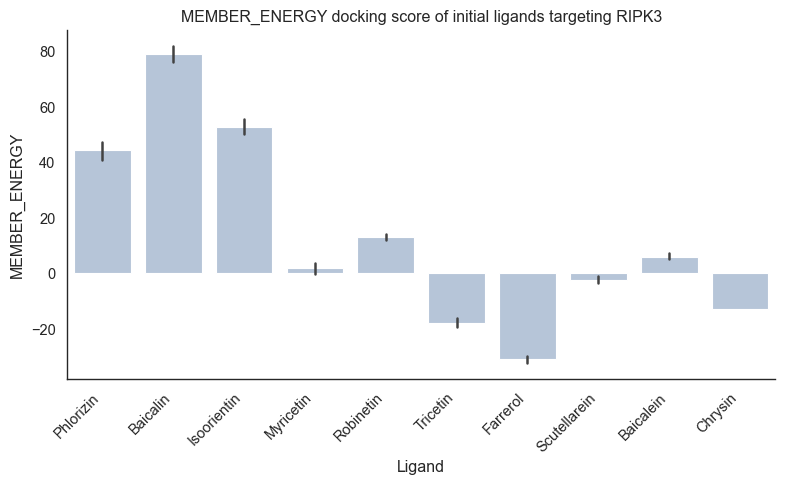

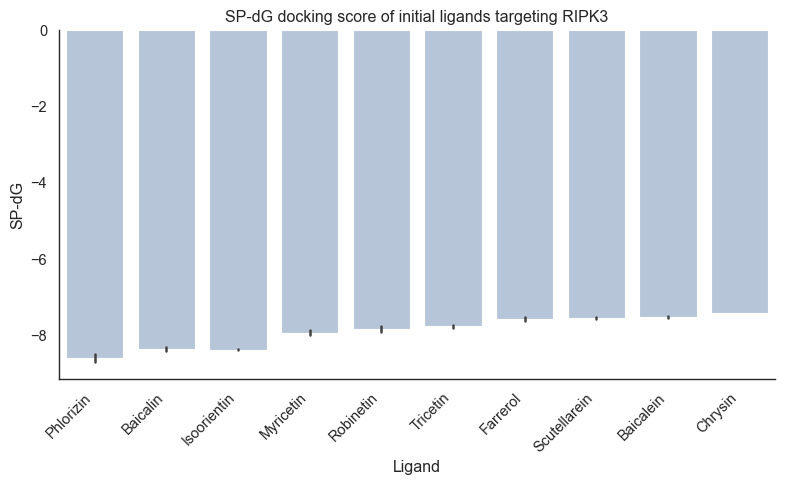

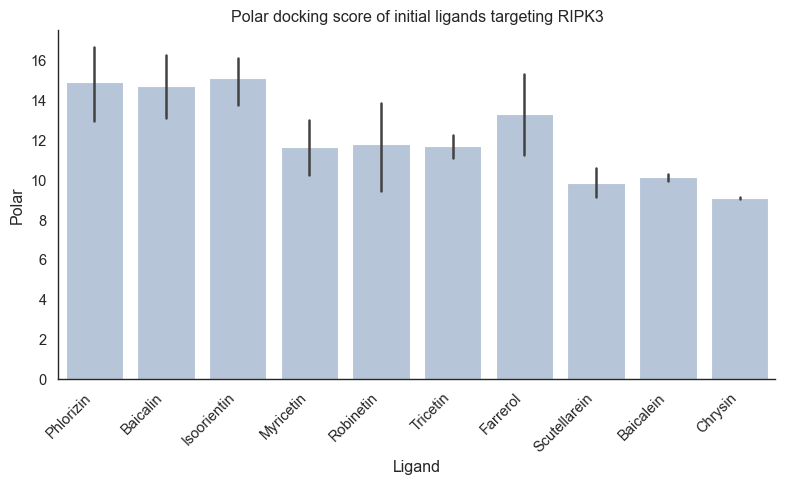

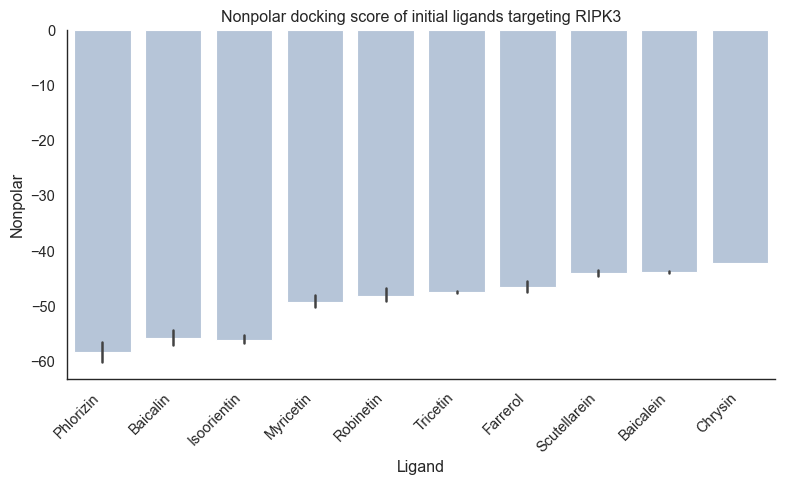

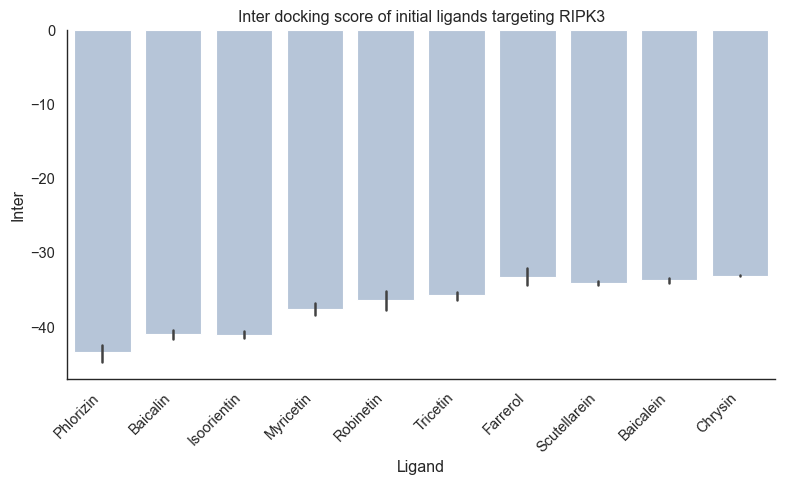

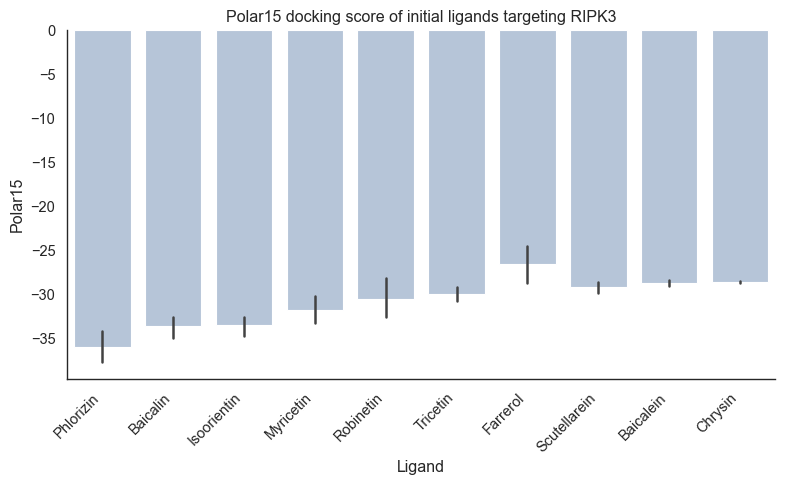

In [9]:
# Plot and save docking energy metrics for the top docking poses of each ligand
sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.2
)

df_plot = df_remarks_top_ten.sort_values("SP-dG", ascending=True)

for prop in energy_cols:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=df_plot,
        x="ligand",
        y=prop,
        color="lightsteelblue"
    )

    plt.ylabel(f"{prop}")
    plt.xlabel("Ligand")
    plt.title(f"{prop} docking score of initial ligands targeting RIPK3")

    plt.xticks(rotation=45, ha="right")

    sns.despine()

    plt.tight_layout()
    plt.savefig(f"figures\\{prop}_flavonoids_ligands.png", dpi=300)
    plt.show()

In [10]:
# Protein
file_prot = "swissdock_results\\receptor.pdb"

dicc_coords_prot = {'record_name' : [],
                    'atom_serial' : [],
                    'atom_name' : [],
                    'residue_name' : [],
                    'residue_number' : [],
                    'x' : [],
                    'y' : [],
                    'z' : [],
                    'occupancy' : [],
                    'b_factor' : [],
                    'segment_id' : []}

with open(file_prot, "r") as f:
    for line in f:
        if 'ATOM' in line:
            linea = line.strip()
            coord_values = linea.split()
            dicc_coords_prot['record_name'].append(coord_values[0])
            dicc_coords_prot['atom_serial'].append(coord_values[1])
            dicc_coords_prot['atom_name'].append(coord_values[2])
            dicc_coords_prot['residue_name'].append(coord_values[3])
            dicc_coords_prot['residue_number'].append(coord_values[4])
            dicc_coords_prot['x'].append(coord_values[5])
            dicc_coords_prot['y'].append(coord_values[6])
            dicc_coords_prot['z'].append(coord_values[7])
            dicc_coords_prot['occupancy'].append(coord_values[8])
            dicc_coords_prot['b_factor'].append(coord_values[9])
            dicc_coords_prot['segment_id'].append(coord_values[10])

df_coords_prot = pd.DataFrame.from_dict(dicc_coords_prot)
df_coords_prot[['atom_serial', 'residue_number', 'x', 'y', 'z', 'occupancy', 'b_factor']] = df_coords_prot[['atom_serial', 'residue_number', 'x', 'y', 'z', 'occupancy', 'b_factor']].astype(float)
print(df_coords_prot.columns)


Index(['record_name', 'atom_serial', 'atom_name', 'residue_name',
       'residue_number', 'x', 'y', 'z', 'occupancy', 'b_factor', 'segment_id'],
      dtype='object')


In [11]:
df_coords_prot.to_csv('protein_coords.csv', index=False)

In [12]:
# Extract the coordinates of key protein atoms involved in hydrogen-bond interactions
df_R960 = df_coords_prot[(df_coords_prot['residue_name'] == 'ARG') & (df_coords_prot['residue_number'] == 96) & (df_coords_prot['atom_name'] == 'O')]
coords_R960 = df_R960[['x','y','z']].to_numpy()
df_T950G1 = df_coords_prot[(df_coords_prot['residue_name'] == 'THR') & (df_coords_prot['residue_number'] == 95) & (df_coords_prot['atom_name'] == 'OG1')]
coords_T950G1 = df_T950G1[['x','y','z']].to_numpy()
df_M98N = df_coords_prot[(df_coords_prot['residue_name'] == 'MET') & (df_coords_prot['residue_number'] == 98) & (df_coords_prot['atom_name'] == 'N')]
coords_M98N = df_M98N[['x','y','z']].to_numpy()

coord_ARG96_O = coords_R960[0]
coord_THR95_OG1 = coords_T950G1[0]
coord_MET98_N = coords_M98N[0]

In [13]:
# Function to calculate distance between two points
def dist(a, b):
    return np.linalg.norm(a - b)

In [14]:
# Calculate hydrogen-bond distances for Tricetin and Robinetin docking poses
results = []

ligand = "Tricetin"

for key, df_lig in dicc_coords_master[ligand].items():

    # Keep only O2 and O3
    df_O2 = df_lig[df_lig["atom_name"]=="O2"]
    df_O3 = df_lig[df_lig["atom_name"]=="O3"]

    coord_O2 = df_O2[["x", "y", "z"]].iloc[0].to_numpy()
    coord_O3 = df_O3[["x", "y", "z"]].iloc[0].to_numpy()

    #R96
    results.append({
        'ligand': ligand,
        'seed': key,
        'dist_R96_O2': dist(coord_O2, coord_ARG96_O),
        'dist_R96_O3': dist(coord_O3, coord_ARG96_O),
        'dist_T95_O2': dist(coord_O2, coord_THR95_OG1),
        'dist_M98_O3': dist(coord_O3, coord_MET98_N),
    })

ligand = "Robinetin"

for key, df_lig in dicc_coords_master[ligand].items():

    # Keep only O2 and O3
    df_O4 = df_lig[df_lig["atom_name"]=="O4"]
    df_O3 = df_lig[df_lig["atom_name"]=="O3"]

    coord_O4 = df_O4[["x", "y", "z"]].iloc[0].to_numpy()
    coord_O3 = df_O3[["x", "y", "z"]].iloc[0].to_numpy()

    results.append({
        'ligand': ligand,
        'seed': key,
        'dist_R96_O4': dist(coord_O4, coord_ARG96_O),
        'dist_R96_O3': dist(coord_O3, coord_ARG96_O),
        'dist_T95_O3': dist(coord_O3, coord_THR95_OG1),
        'dist_M98_O4': dist(coord_O4, coord_MET98_N),
    })

df_distances = pd.DataFrame(results)

In [15]:
# Merge the docking metadata with the calculated hydrogen-bond distances
df_merge = df_remarks.merge(df_distances, on=['ligand', 'seed'])
df_merge = df_merge.drop(columns=['FILE_NAME', 'CLUSTER_NUM', 'CLUSTER_MEMBER', 'MEMBER_ENERGY', 'RMSD'])

In [16]:
# Filter Robinetin docking poses and calculate the sum of hydrogen-bond distances
df_rob = df_merge[df_merge['ligand']=='Robinetin']
df_rob = df_rob.dropna(axis=1)
df_rob['sum_dists'] = df_rob['dist_R96_O3'] + df_rob['dist_T95_O3'] + df_rob['dist_R96_O4'] + df_rob['dist_M98_O4']

df_rob_filtered = df_rob[df_rob['SP-dG']<-5]
print(df_rob.shape)
print(df_rob_filtered.shape)

(182, 14)
(174, 14)


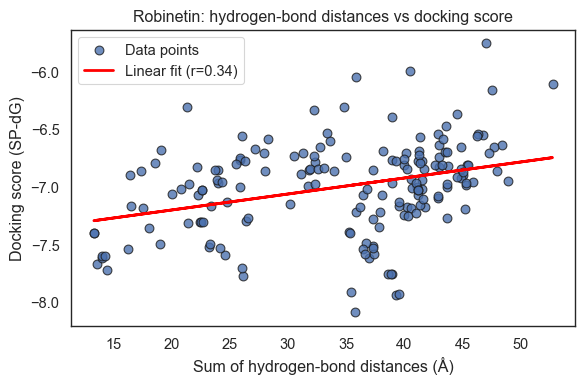

In [17]:
# Assess the correlation between hydrogen-bond distances and docking score
x = df_rob_filtered['sum_dists']
y = df_rob_filtered['SP-dG']

m, b = np.polyfit(x, y, 1)
y_fit = m * x + b

r, p_value = pearsonr(x, y)

plt.figure(figsize=(6, 4))

plt.scatter(
    x, y,
    s=40,
    alpha=0.8,
    edgecolors='k',
    label='Data points'
)

plt.plot(x, y_fit, color='red', linewidth=2, label=f'Linear fit (r={r:.2f})')

plt.xlabel('Sum of hydrogen-bond distances (Å)')
plt.ylabel('Docking score (SP-dG)')
plt.title('Robinetin: hydrogen-bond distances vs docking score')

plt.legend()

plt.grid(False)
plt.tight_layout()

plt.show()

In [18]:
print('Robinetin')
print(f'r:{r}')
print(f'p-value: {p_value}')

Robinetin
r:0.33673678289037107
p-value: 5.53955111629067e-06


In [19]:
# Filter Tricetin docking poses and calculate the sum of hydrogen-bond distances
df_tric = df_merge[df_merge['ligand']=='Tricetin']
df_tric = df_tric.dropna(axis=1)
df_tric['sum_dists'] = df_tric['dist_R96_O2'] + df_tric['dist_R96_O3'] + df_tric['dist_T95_O2'] + df_tric['dist_M98_O3']

df_tric_filtered = df_tric[df_tric['SP-dG']<-5]
print(df_tric.shape)
print(df_tric_filtered.shape)

(203, 14)
(199, 14)


In [20]:
print('Tricetin')
print(f'r:{r}')
print(f'p-value: {p_value}')

Tricetin
r:0.33673678289037107
p-value: 5.53955111629067e-06


In [21]:
# Top 15% (most favorable docking poses)
df_remarks_top_pct = df_remarks.copy()
n_total = df_remarks_top_pct.shape[0]
n_top_pct = int(n_total * 0.15)
df_remarks_top_pct = df_remarks_top_pct.sort_values(by='SP-dG')
df_remarks_top_pct = df_remarks_top_pct.head(n_top_pct)
df_remarks_top_pct.to_csv("df_remarks_top_pct.csv", index=False)

In [22]:
print(df_remarks_top_pct['ligand'].value_counts())

ligand
Phlorizin      86
Isoorientin    71
Baicalin       70
Myricetin      16
Tricetin       15
Robinetin      11
Farrerol        4
Name: count, dtype: int64
